# Synthetic Data Generation:

In this file, we are going to create synthetic data that will be used to train the model to create a *portfolio recommendation system*.  

There are 5 practical ways to generate synthetic financial data:  
1. **Rule based generation** - Creating data using financial rules and sample users from distribution.  
[This is simple and effective for MVP.]


2. **Probabilistic Sampling** - Using statistical distributions, then computing portfolio labels using finance formulas.  
[This will add *randomness* to the data created earlier.]

3. **Monte Carlo portfolio simulation** - Simulating existing data of stocks,bonds,returns. Then, generate *random portfolios*, calculate *sharpe ratio/volatility* and then label best portfolio for each investor profile.  
[This will be more effective than any other. We will use this technique after creating our MVP.]  

4. **Template based Sampling**

5. **Generative ML models** - Using *reinforcement learning*. This is very advanced. We will use it in later stages.

### Industry based financial rules to create data
1. **Age and equity**: equity% = (100 - age)% [20%-80%]
   *The core idea is that younger investors can afford higher risk.*

2. **Risk Apetite**:

*   Low Risk - equity(-25%), MF(+15%), Cash(+10%)
*   Medium Risk - No Change
*   High Risk - equity(+20%), MF(-10%), Cash(-10%)

3. **Goal based allocation**:

*   Wealth Creation - equity(+15%), MF(-10%), Cash(-5%)
*   Passive Income - equity(-10%), MF(+15%), Cash(-5%)
*   Capital Preserve - equity(-20%), MF(+10%), Cash(+10%)
*   Short-term Goal - equity(-25%), MF(+10%), Cash(+15%)
*   Retirement:
     1. If *AGE < 45*: equity(+10%), MF(-5%), Cash(-5%)
     2. If *AGE >= 45*: equity(-10%), MF(+5%), Cash(+5%)


4. **Horizon Cap**: Longer horizon => More equity
    * Horizon < 3years = equity max 30%
    * 3-7 years = equty max 60%
    * More than 7 years = allow 80-90%

5. **Emergency liquid rule**: Set *minimum* cash - **cash>=5%**

6. **Mutual Fund allocation**: 100 - Cash% - Equity%

7. Clamping + Normalising the percentage
      














In [ ]:
# Creating function that will generate random user profiles

import random
import numpy as np

random.seed(42)

# using normal distribution to create age data with mean age=25 and std=4
def sample_age():
  age = int(random.gauss(25,4))
  return max(18, min(60,age))

  """
    Similar for capital distribition ~ around 30000rs;
    using "log-normal dist"; it will help in long run
    as large capital amount can hallucianate the data.
    Lognormal is close to real wealth distribution.
    Search on the web for the formula.

  """
def sample_capital():
  cap = int(np.random.lognormal(mean=10.1, sigma=0.35))
  return max(5000, min(100000, cap)) # clamping the capital between 5k-100k

def sample_horizon():
  hzn = int(random.gauss(5,2))
  return max(3, min(15, hzn))

def generate_user():
  return {
      "age": sample_age(),
      "risk": random.choice(["low", "medium", "high"]),
      "goal": random.choice(["wealth", "income","preservation","short_term","retirement"]),
      "horizon": sample_horizon(),
      "capital": sample_capital()
  }

In [ ]:
# Allocation based on age
def age_rule(age):
  e = max(20, min(80, 100-age))
  c = 5
  m = 100-e-c
  return e, m, c


# Adjusting risk apetite
def risk_rule(e,m,c,risk):
  if risk == "low":
    e -= 25; m += 15; c += 10
  elif risk == "high":
    e += 20; m -= 10; c -= 10
  return e,m,c


# Goal based adjustment:
def  goal_rule(e,m,c,goal,age):
  if goal == "wealth":
    e += 15; m -= 10; c -= 5
  elif goal == "income":
    e -= 10; m += 15; c -= 5
  elif goal == "preservation":
    e -= 20; m += 10; c += 10
  elif goal == "short_term":
    e -= 25; m += 10; c += 15
  elif goal == "short_term":
    if age < 45:
      e += 10; m -= 5; c -= 5
    else:
      e -= 10; m += 5; c += 5
  return e, m, c


# Adjustment due to "horizon cap"
def horizon_rule(e,m,c,horizon):
  if horizon < 3:
    e = min(e,30)
  elif horizon > 3 and horizon < 7:
    e = min(e,60)
  return e,m,c


# Final normalization and safety clamping
def finalize(e,m,c):

  # minimum cash
  c = max(c,5)

  # Recompute MF if needed
  total = e + m + c
  e,m,c = [x*100/total for x in (e,m,c)]

  # Clamping ranges
  e = min(max(10,e),85)
  m = min(max(10,m),80)
  c = min(max(5,c),20)

  # Normalize again
  total = e + m + c
  return [round(x*100/total, 2) for x in (e,m,c)] # rounding the %age to 2 decimal places

In [ ]:
# Combining all the functions

def generate_portfolio(user):
  e,m,c = age_rule(user["age"])
  e,m,c = risk_rule(e,m,c,user["risk"])
  e,m,c = goal_rule(e,m,c, user["goal"], user["age"])
  e,m,c = horizon_rule(e,m,c, user["horizon"])
  e,m,c = finalize(e,m,c)
  return e,m,c

In [ ]:
# Creating dataset based on above rules
import pandas as pd

rows=[]
for _ in range(10000):
  user = generate_user()
  e,m,c = generate_portfolio(user)

  rows.append({
      **user,   # "**user" is dictionary unpacking in python - expands to age, risk, goal, horizon, capital
      "equity":e,
      "mf":m,
      "cash":c})
df = pd.DataFrame(rows)
df.to_csv("synthetic_portfolios.csv", index=False)

Now, we have created the synthetic datset, now we will analyse the data, and try to explore the data, and find the relation between different parameters(features).  

So, let's perform EDA and understand the data. We have 10000 different portfolio distribution depending on the 8 features, which are-  
1. Age
2. Risk
3. Horizon
4. capital
5. goal  
giving us the distribution of equity, mf, cash.

# Exploratory Data Analysis

In [ ]:
df.head()

,age,risk,goal,horizon,capital,equity,mf,cash
0,24,medium,income,4,33868,60.61,34.34,5.05
1,26,high,retirement,8,18910,85.00,10.00,5.00
2,28,low,wealth,6,25194,61.22,28.57,10.20
3,25,low,retirement,7,22674,50.00,35.00,15.00
4,26,high,short_term,7,15662,69.00,21.00,10.00


In [ ]:
df.describe()

,age,horizon,capital,equity,mf,cash
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,24.55790,4.754900,26072.522500,60.792828,28.220142,10.986918
std,3.80606,1.660452,9532.241419,17.639400,13.028774,6.089455
min,18.00000,3.000000,5802.000000,14.440000,9.680000,4.970000
25%,22.00000,3.000000,19152.750000,49.000000,18.750000,5.210000
50%,24.00000,5.000000,24515.500000,63.830000,26.970000,10.000000
75%,27.00000,6.000000,31077.000000,75.000000,36.000000,15.000000
max,38.00000,14.000000,87625.000000,85.000000,63.330000,22.220000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   age      10000 non-null  int64  
 1   risk     10000 non-null  object 
 2   goal     10000 non-null  object 
 3   horizon  10000 non-null  int64  
 4   capital  10000 non-null  int64  
 5   equity   10000 non-null  float64
 6   mf       10000 non-null  float64
 7   cash     10000 non-null  float64
dtypes: float64(3), int64(3), object(2)
memory usage: 625.1+ KB


In [ ]:
# Checking logical error ~ sum of distribution of wealth in all areas equals 100.
(df["equity"]+df["mf"]+df["cash"]).describe()

,0
count,10000.000000
mean,99.999888
std,0.003372
min,99.990000
25%,100.000000
50%,100.000000
75%,100.000000
max,100.010000


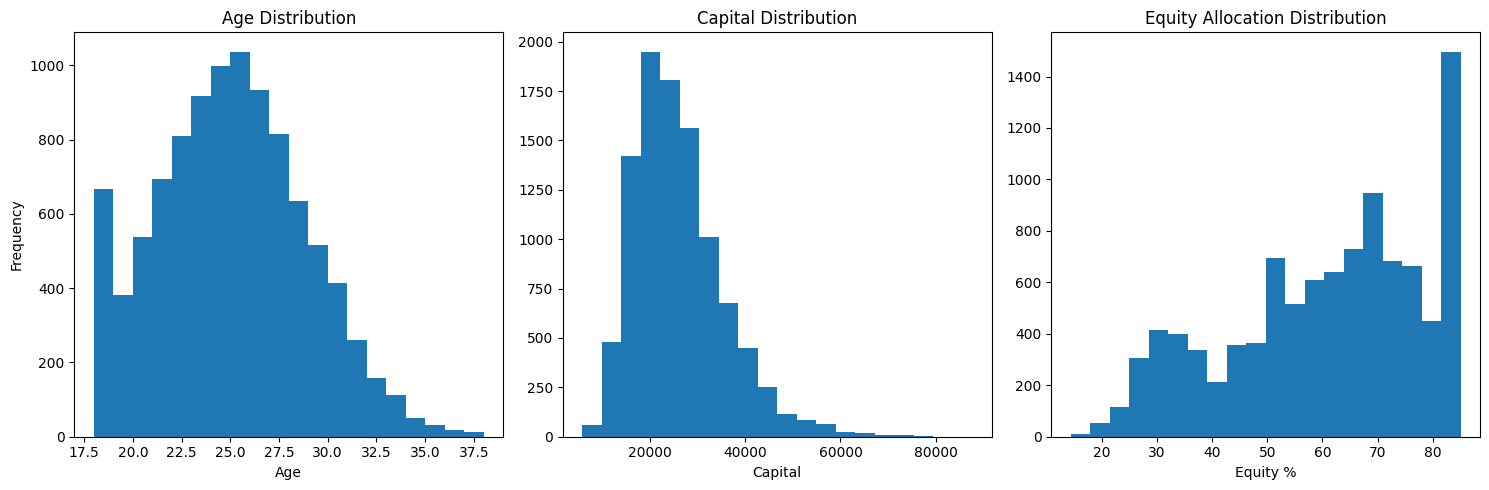

In [ ]:
# Visualising the distribution of features

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1,3, figsize=(15,5))

# Age
axes[0].hist(df["age"], bins=20)
axes[0].set_title("Age Distribution")
axes[0].set_xlabel("Age")
axes[0].set_ylabel("Frequency")

# Capital
axes[1].hist(df["capital"], bins=20)
axes[1].set_title("Capital Distribution")
axes[1].set_xlabel("Capital")

# Equity
axes[2].hist(df["equity"], bins=20)
axes[2].set_title("Equity Allocation Distribution")
axes[2].set_xlabel("Equity %")

plt.tight_layout()
plt.show()

In [ ]:
# Checing categorical balance
print(df["risk"].value_counts()/100)
print('\n')
print(df['goal'].value_counts()/100)

risk
medium    33.83
low       33.31
high      32.86
Name: count, dtype: float64


goal
short_term      20.62
wealth          20.33
retirement      19.72
preservation    19.70
income          19.63
Name: count, dtype: float64


The distribution of features is general and not biased to any point. Therefore, it will not hallucinate the model.   

Now, we will try to visualise the features correlation.

1. For diff categories of risk, order f equity dist: High > medium > low.


In [ ]:
# Correlation b/w risk and equity
print(df.groupby('risk')['equity'].mean())

print('\n')

# Goal v/s allocation
print(df.groupby("goal")[['equity','mf','cash']].mean())

risk
high      75.477928
low       42.763566
medium    64.280925
Name: equity, dtype: float64


                 equity         mf       cash
goal                                         
income        57.405354  35.885960   6.709542
preservation  52.759543  33.085305  14.154645
retirement    68.243966  22.955583   8.800406
short_term    48.953322  33.455010  17.590902
wealth        76.628834  15.900930   7.470172


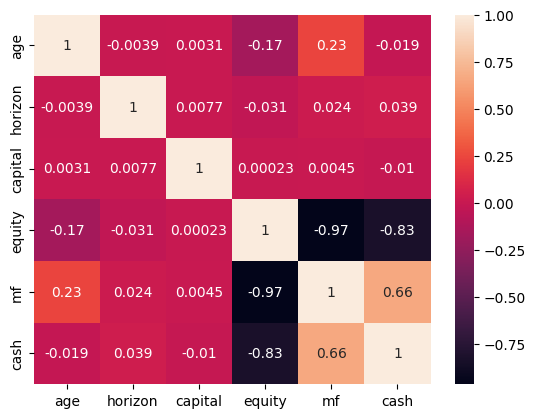

In [ ]:
# Correlation Matrix
import seaborn as sns
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.show()

Now, Encoding the numerical values to the features that are categorical such as "Risk" and "Goal".  

1. Using "Ordinal encoding" to encode "risk" as it follows the natural order.
2. Using "One-hot encoding" to encode "goal" as it contains the multiple features.

In [ ]:
# Encoding Risk - Ordinal encoding
risk_map = {"low":0, "medium":1, "high":2}
df['risk'] = df['risk'].map(risk_map)

# Encoding Goal - OneHot encoding
df = pd.get_dummies(df, columns=['goal'], drop_first=True)


After encoding with `drop_first=True`, you get 4 columns.The dropped one becomes the baseline category. If all 4 values are False, then automatically the dropped one will be the answer(income).

In [ ]:
df.head()

,age,risk,horizon,capital,equity,mf,cash,goal_preservation,goal_retirement,goal_short_term,goal_wealth
0,24,1,4,33868,60.61,34.34,5.05,False,False,False,False
1,26,2,8,18910,85.00,10.00,5.00,False,True,False,False
2,28,0,6,25194,61.22,28.57,10.20,False,False,False,True
3,25,0,7,22674,50.00,35.00,15.00,False,True,False,False
4,26,2,7,15662,69.00,21.00,10.00,False,False,True,False


In [ ]:
df.to_csv('dataS.csv')

In [ ]:
from google.colab import files
files.download('dataS.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>